In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from sklearn.linear_model import LinearRegression

In [183]:
#Data from Copernicus : https://climate.copernicus.eu/copernicus-2024-world-experienced-warmest-january-record
# Open the CSV file
file_path = '/Users/epauthen/Documents/Database/timeseries_era5_daily_sst_60S-60N_data_2.csv'

# Load the CSV file into a DataFrame
data = pd.read_csv(file_path, delimiter=';')
ds = xr.Dataset.from_dataframe(data)
ds = xr.Dataset.from_dataframe(data.set_index('date'))
ds['date'] = ds['date'].astype('datetime64')

ds['day_of_year'] = ds['date'].dt.dayofyear
ds['year'] = ds['date'].dt.year
ds = ds.set_coords('day_of_year')
ds = ds.set_coords('year')

ds1997 = ds.where(year==1997)
ds1998 = ds.where(year==1998)
ds2023 = ds.where(year==2023)
ds2024 = ds.where(year==2024)

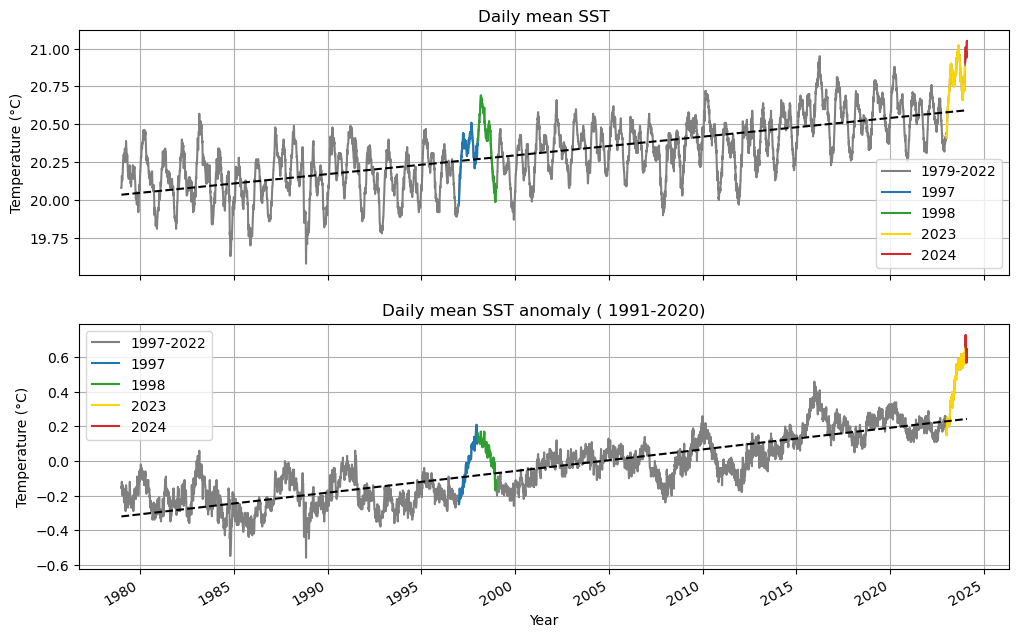

In [184]:
# Plotting
fig, (ax1,ax2) = plt.subplots(2, 1,figsize = (12,7))
ds['sst'].plot(label='1979-2022',color = 'grey',ax = ax1)
ds1997['sst'].plot(label='1997', color='tab:blue',ax = ax1)
ds1998['sst'].plot(label='1998', color='tab:green',ax = ax1)
ds2023['sst'].plot(label='2023', color='gold',ax = ax1)
ds2024['sst'].plot(label='2024', color='tab:red',ax = ax1)
ax1.set_title('Daily mean SST')

ds['ano_91-20'].plot(label='1997-2022', color='grey',ax = ax2)
ds1997['ano_91-20'].plot(label='1997', color='tab:blue',ax = ax2)
ds1998['ano_91-20'].plot(label='1998', color='tab:green',ax = ax2)
ds2023['ano_91-20'].plot(label='2023', color='gold',ax = ax2)
ds2024['ano_91-20'].plot(label='2024', color='tab:red',ax = ax2)
ax2.set_title('Daily mean SST anomaly ( 1991-2020)')

# Linear regression for daily SST
x_values = np.arange(len(ds['date'])).reshape(-1, 1)
y_values = ds['sst'].values.reshape(-1, 1)
model = LinearRegression()
model.fit(x_values, y_values)
regression_line = model.predict(x_values)
slope = np.round(model.coef_[0][0]*3650,2)
ax1.plot(ds['date'], regression_line, linestyle='--', color='black')

# Linear regression for anomaly
x_values = np.arange(len(ds['date'])).reshape(-1, 1)
y_values = ds['ano_91-20'].values.reshape(-1, 1)
model = LinearRegression()
model.fit(x_values, y_values)
regression_line = model.predict(x_values)
slope = np.round(model.coef_[0][0]*3650,2)
ax2.plot(ds['date'], regression_line, linestyle='--', color='black') #label=f"Slope of the linear regression: {slope} °C/year"

ax1.set_xlabel('')
ax2.set_xlabel('Year')
ax1.set_xticklabels([])

for ax in (ax1,ax2):
    ax.set_ylabel('Temperature (°C)')
    ax.legend()
    ax.grid()
plt.savefig('Fig_SST.png')

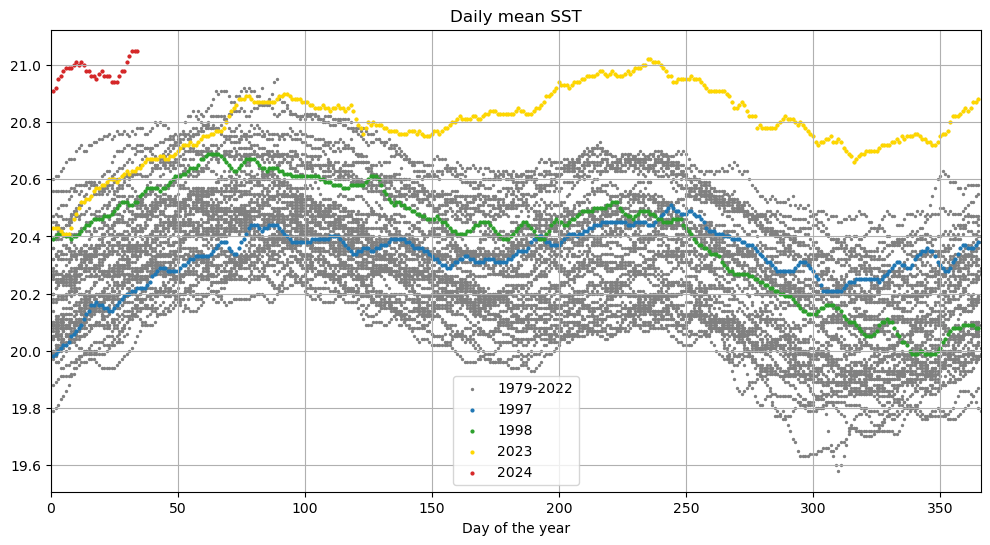

In [185]:
#Against day of the year for dramatic effect
plt.figure(figsize=(12, 6))
plt.scatter(ds['day_of_year'], ds['sst'], color='grey',s = 2, label = '1979-2022')
plt.scatter(ds1997['day_of_year'], ds1997['sst'], label='1997',s = 4,color = "tab:blue")
plt.scatter(ds1998['day_of_year'], ds1998['sst'], label='1998',s = 4,color = "tab:green")
plt.scatter(ds2023['day_of_year'], ds2023['sst'], label='2023',s = 4,color = "gold")
plt.scatter(ds2024['day_of_year'], ds2024['sst'], label='2024',s = 4,color = "tab:red")

plt.legend()
plt.grid()
plt.xlim([0,366])
plt.xlabel('Day of the year')
plt.title('Daily mean SST')
plt.savefig('Fig_SST2.png')